In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
def import_csv(url, date_cols=None):
    path = "https://drive.google.com/uc?export=download&id=" + url.split("/")[-2]
    return pd.read_csv(path, parse_dates=date_cols)

# orders_cl.csv
orders_url = "https://drive.google.com/file/d/1clMQ_JgII9h6FX931gFN5bjqstwR2FNe/view?usp=drive_link"


# orderlines_cl.csv
orderlines_url = "https://drive.google.com/file/d/1L8q-smVIRmn_SpGgDfsVtDZ_7-wtda-j/view?usp=drive_link"


# products_cl.csv
products_url = "https://drive.google.com/file/d/1EEwu-HCrbFSYNO7mloYIHUKf4JuO2cSG/view?usp=drive_link"

# brands_cl.csv
brands_url = "https://drive.google.com/file/d/1KC0MkwOPXrWZ7zWpIuNG5TCJvpIkuejd/view?usp=drive_link"


orders_df = import_csv(orders_url, ["created_date"])
orderlines_df = import_csv(orderlines_url, ["date"])
products_df = import_csv(products_url)
brands_df = import_csv(brands_url)
print("Orders:", orders_df.shape[0])
print("Orderlines:", orderlines_df.shape[0])

Orders: 226904
Orderlines: 216250


## **Quality Assesment**

In [120]:
# exclude orders with items that don't appear in products
orderlines_products = orderlines_df.merge(products_df, how="left", on = "sku")[["order_id","sku","name" ]]

orders_to_delete = orderlines_products.loc[orderlines_products["name"].isna(), "order_id"].unique()

orderlines_df = orderlines_df.loc[~orderlines_df["order_id"].isin(orders_to_delete)]

# Remove rows with unknown product price
products_df = products_df.loc[products_df["price"].notna()].copy()



In [121]:
# keep only completed orders
orders_df = orders_df.loc[orders_df["state"] == "Completed"]
orders_df

,order_id,created_date,total_paid,state
1,241423,2017-11-06 13:10:02,136.15,Completed
2,242832,2017-12-31 17:40:03,15.76,Completed
3,243330,2017-02-16 10:59:38,84.98,Completed
5,245275,2017-06-28 11:35:37,149.00,Completed
6,245595,2017-01-21 12:52:47,112.97,Completed
...,...,...,...,...
226544,527042,2018-03-14 11:47:50,18.98,Completed
226572,527070,2018-03-14 11:50:48,24.97,Completed
226576,527074,2018-03-14 11:51:42,24.97,Completed
226598,527096,2018-03-14 11:58:40,34.96,Completed


In [122]:
# keep only orders that appear in both orderlines and orders

orders_orderlines = orders_df.merge(orderlines_df, how="inner", on="order_id")

# order_ids that are in both tables
order_ids_to_keep = orders_orderlines["order_id"].unique()

# keep those ids in orders
orders_df = orders_df.loc[orders_df["order_id"].isin(order_ids_to_keep)].copy()

# keep those ids in orderlines
orderlines_df = orderlines_df.loc[orderlines_df["order_id"].isin(order_ids_to_keep)].copy()

In [123]:
orders_df.shape[0], orderlines_df.shape[0], products_df.shape[0]

(42208, 55228, 10157)

In [124]:
orderlines_products = orderlines_df.merge(products_df, how="left", on = "sku")

orderlines_products["short"] = orderlines_products["sku"].str[:3]

brands_orderlines_products = pd.merge(
    orderlines_products,
    brands_df,
    on="short",
    how="left"
)
brands_orderlines_products

,order_id,product_quantity,sku,unit_price,date,unit_total,name,desc,price,type,short,long
0,299545,1,OWC0100,47.49,2017-01-01 01:46:16,47.49,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,12755395,OWC,OWC
1,299546,1,IOT0014,18.99,2017-01-01 01:50:34,18.99,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,5720,IOT,iOttie
2,295347,1,APP0700,72.19,2017-01-01 01:54:11,72.19,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,13005399,APP,Apple
3,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,60.90,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,1298,CRU,Crucial
4,299561,1,PEB0015,142.49,2017-01-01 02:38:50,142.49,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,11905404,PEB,Pebble
...,...,...,...,...,...,...,...,...,...,...,...,...
55223,525664,1,TUC0207,16.52,2018-03-14 11:45:05,16.52,Tucano Elements Second Skin Macbook Sleeve 12 ...,velvety inner protective case for MacBook 12 i...,24.99,13835403,TUC,Tucano
55224,527070,2,APP0698,9.99,2018-03-14 11:49:01,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,APP,Apple
55225,527074,2,APP0698,9.99,2018-03-14 11:49:36,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,APP,Apple
55226,527096,3,APP0698,9.99,2018-03-14 11:54:35,29.97,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,APP,Apple


# **CATEGORIES CLASSIFICATION**

In [125]:
products_df["category"] = ""
products_df.head()

,sku,name,desc,price,type,category
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,13855401,
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,1387,
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,1230,
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1364,


In [126]:
pd.set_option('display.max_rows', 1000)

In [127]:
products_df.loc[products_df["type"] == "11865403", "category"] = "Smartphone & Mobile Accessories"
products_df.loc[products_df["type"] == "12175397", "category"] = "Storage Devices"
products_df.loc[products_df["type"] == "11935397", "category"] = "Storage Devices"
products_df.loc[products_df["type"] == "11905404", "category"] = "Networking & Connectivity"
products_df.loc[products_df["type"] == "1282", "category"] = "Laptops & Notebooks"
products_df.loc[products_df["type"] == "12635403", "category"] = "Smartphone & Mobile Accessories"
products_df.loc[products_df["type"] == "13835403", "category"] = "Smartphone & Mobile Accessories"
products_df.loc[products_df["type"] == "5,74E+15", "category"] = "Monitors"
products_df.loc[products_df["type"] == "1364", "category"] = "Storage Devices"
products_df.loc[products_df["type"] == "12585395", "category"] = "Cables & Adapters"
products_df.loc[products_df["type"] == "1296", "category"] = "Monitors"
products_df.loc[products_df["type"] == "1325", "category"] = "Cables & Adapters"
products_df.loc[products_df["type"] == "5384", "category"] = "Headsets/Headphones"
products_df.loc[products_df["type"] == "1433", "category"] = "Storage Devices"
products_df.loc[products_df["type"] == "12215397", "category"] = "Storage Devices"
products_df.loc[products_df["type"] == "5398", "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["type"] == "1,02E+12", "category"] = "Laptops & Notebooks"
products_df.loc[products_df["type"] == "1,44E+4", "category"] = "Repair & Services"
products_df.loc[products_df["type"] == "57445397", "category"] = "Storage Devices"
products_df.loc[products_df["type"] == "1334", "category"] = "Networking Equipment"
products_df.loc[products_df["type"] == "2158", "category"] = "Laptops & Notebooks"
products_df.loc[products_df["type"] == "2449", "category"] = "Accessories"
products_df.loc[products_df["type"] == "12655397", "category"] = "Storage Devices"
products_df.loc[products_df["type"] == "1229", "category"] = "Accessories"
products_df.loc[products_df["type"] == "12995397", "category"] = "Docking Station & Expansion Units"
products_df.loc[products_df["type"] == "1515", "category"] = "Portable Charges & Powerbanks"
products_df.loc[products_df["type"] == "13615399", "category"] = "Docking Station & Expansion Units"
products_df.loc[products_df["type"] == "13555403", "category"] = "Accessories"
products_df.loc[products_df["type"] == "1405", "category"] = "Tablets"
products_df.loc[products_df["type"] == "1230", "category"] = "Cables & Adapters"
products_df.loc[products_df["type"] == "118692158", "category"] = "Monitors"
products_df.loc[products_df["type"] == "1216", "category"] = "Accessories"
products_df.loc[products_df["type"] == "24885185", "category"] = "Wearables"
products_df.loc[products_df["type"] == "24895185", "category"] = "Wearables"
products_df.loc[products_df["type"] == "21485407", "category"] = "Repair & Services"
products_df.loc[products_df["type"] == "1392", "category"] = "Accessories"
products_df.loc[products_df["type"] == "11821715", "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["type"] == "8696", "category"] = "Accessories"
products_df.loc[products_df["type"] == "9094", "category"] = "Security & Surveillance"
products_df.loc[products_df["type"] == "5,39E+11", "category"] = "Laptops & Notebooks"
products_df.loc[products_df["type"] == "5,49E+11", "category"] = "Smartphone & Mobile Accessories"
products_df.loc[products_df["type"] == "42945397", "category"] = "Storage Devices"
products_df.loc[products_df["type"] == "12645406", "category"] = "Repair Toolkits"
products_df.loc[products_df["type"] == "51601716", "category"] = "Smartphones & Mobiles"
products_df.loc[products_df["type"] == "2,16E+11", "category"] = "Monitors"
products_df.loc[products_df["type"] == "85651716", "category"] = "Smartphones & Mobiles"
products_df.loc[products_df["type"] == "24215399", "category"] = "Power & Charging"
products_df.loc[products_df["type"] == "5720", "category"] = "Accessories"
products_df.loc[products_df["type"] == "14305406", "category"] = "Repair Toolkits"
products_df.loc[products_df["type"] == "11865403", "category"] = "Accessories"
products_df.loc[products_df["type"] == "12175397", "category"] = "Networking & Connectivity"
products_df.loc[products_df["type"] == "11935397", "category"] = "Computer Accessories"
products_df.loc[products_df["type"] == "11905404", "category"] = "Computer Accessories"
products_df.loc[products_df["type"] == "1282", "category"] = "Computers"
products_df.loc[products_df["type"] == "12635403", "category"] = "Accessories"
products_df.loc[products_df["type"] == "13835403", "category"] = "Accessories"
products_df.loc[products_df["type"] == "5,74E+15", "category"] = "Computers"
products_df.loc[products_df["type"] == "1364", "category"] = "Computer Accessories"
products_df.loc[products_df["type"] == "12585395", "category"] = "Networking & Connectivity"
products_df.loc[products_df["type"] == "1296", "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["type"] == "1325", "category"] = "Networking & Connectivity"
products_df.loc[products_df["type"] == "5384", "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["type"] == "1433", "category"] = "Computer Accessories"
products_df.loc[products_df["type"] == "12215397", "category"] = "Computer Accessories"
products_df.loc[products_df["type"] == "5398", "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["type"] == "1,02E+12", "category"] = "Computers"
products_df.loc[products_df["type"] == "1,44E+4", "category"] = "Repair & Services"
products_df.loc[products_df["type"] == "57445397", "category"] = "Computer Accessories"
products_df.loc[products_df["type"] == "1334", "category"] = "Networking & Connectivity"
products_df.loc[products_df["type"] == "2158", "category"] = "Computers"
products_df.loc[products_df["type"] == "2449", "category"] = "Accessories"
products_df.loc[products_df["type"] == "12655397", "category"] = "Computer Accessories"
products_df.loc[products_df["type"] == "1229", "category"] = "Accessories"
products_df.loc[products_df["type"] == "12995397", "category"] = "Networking & Connectivity"
products_df.loc[products_df["type"] == "1515", "category"] = "Power & Charging"
products_df.loc[products_df["type"] == "13615399", "category"] = "Networking & Connectivity"
products_df.loc[products_df["type"] == "13555403", "category"] = "Accessories"
products_df.loc[products_df["type"] == "1405", "category"] = "Accessories"
products_df.loc[products_df["type"] == "1230", "category"] = "Networking & Connectivity"
products_df.loc[products_df["type"] == "118692158", "category"] = "Computers"
products_df.loc[products_df["type"] == "1216", "category"] = "Accessories"
products_df.loc[products_df["type"] == "24885185", "category"] = "Accessories"
products_df.loc[products_df["type"] == "24895185", "category"] = "Accessories"
products_df.loc[products_df["type"] == "21485407", "category"] = "Repair & Services"
products_df.loc[products_df["type"] == "1392", "category"] = "Accessories"
products_df.loc[products_df["type"] == "11821715", "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["type"] == "8696", "category"] = "Accessories"
products_df.loc[products_df["type"] == "9094", "category"] = "Security & Surveillance"
products_df.loc[products_df["type"] == "5,39E+11", "category"] = "Computers"
products_df.loc[products_df["type"] == "5,49E+11", "category"] = "Power & Charging"
products_df.loc[products_df["type"] == "42945397", "category"] = "Computer Accessories"
products_df.loc[products_df["type"] == "12645406", "category"] = "Repair & Services"
products_df.loc[products_df["type"] == "51601716", "category"] = "Smartphones & Mobiles"
products_df.loc[products_df["type"] == "2,16E+11", "category"] = "Computers"
products_df.loc[products_df["type"] == "85651716", "category"] = "Smartphones & Mobiles"
products_df.loc[products_df["type"] == "24215399", "category"] = "Power & Charging"
products_df.loc[products_df["type"] == "5720", "category"] = "Accessories"
products_df.loc[products_df["type"] == "14305406", "category"] = "Repair & Services"
products_df.loc[products_df["name"].str.contains("iphone", case=False), "category"] = "Smartphones & Mobiles"
products_df.loc[products_df["name"].str.contains("charger", case=False), "category"] = "Power & Charging"
products_df.loc[products_df["name"].str.contains("microphone", case=False), "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["name"].str.contains("ipad", case=False), "category"] = "Tablets"
products_df.loc[products_df["name"].str.contains("cellular", case=False), "category"] = "Smartphones & Mobiles"
products_df.loc[products_df["name"].str.contains("keyboard", case=False), "category"] = "Computer Accessories"
products_df.loc[products_df["desc"].str.contains("keyboard", case=False), "category"] = "Computer Accessories"
products_df.loc[products_df["name"].str.contains("keypad", case=False), "category"] = "Computer Accessories"
products_df.loc[products_df["desc"].str.contains("keypad", case=False), "category"] = "Computer Accessories"
products_df.loc[products_df["name"].str.contains("mouse", case=False), "category"] = "Computer Accessories"
products_df.loc[products_df["name"].str.contains("imac", case=False), "category"] = "Monitors"
products_df.loc[products_df["name"].str.contains("macbook", case=False), "category"] = "Laptops & Notebooks"
products_df.loc[products_df["name"].str.contains("license", case=False), "category"] = "Licences & Subscriptions"
products_df.loc[products_df["name"].str.contains("subcription", case=False), "category"] = "Licences & Subscriptions"
products_df.loc[products_df["desc"].str.contains("license", case=False), "category"] = "Licences & Subscriptions"
products_df.loc[products_df["name"].str.contains("installation", case=False), "category"] = "Licences & Subscriptions"
products_df.loc[products_df["desc"].str.contains("installation", case=False), "category"] = "Licences & Subscriptions"
products_df.loc[products_df["desc"].str.contains("subcription", case=False), "category"] = "Licences & Subscriptions"
products_df.loc[products_df["name"].str.contains("ethernet", case=False), "category"] = "Networking & Connectivity"
products_df.loc[products_df["name"].str.contains("apple mac", case=False), "category"] = "Tablets"
products_df.loc[products_df["name"].str.contains("adapter", case=False), "category"] = "Cables & Adapters"
products_df.loc[products_df["name"].str.contains("cable", case=False), "category"] = "Cables & Adapters"
products_df.loc[products_df["desc"].str.contains("cable", case=False), "category"] = "Cables & Adapters"
products_df.loc[products_df["name"].str.contains("port", case=False), "category"] = "Cables & Adapters"
products_df.loc[products_df["desc"].str.contains("port", case=False), "category"] = "Cables & Adapters"
products_df.loc[products_df["name"].str.contains("lamp", case=False), "category"] = "Power & Charging"
products_df.loc[products_df["name"].str.contains("card", case=False), "category"] = "Docking Station & Expansion Units"
products_df.loc[products_df["name"].str.contains("protector", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("protector", case=False), "category"] = "Accessories"
products_df.loc[products_df["name"].str.contains("battery", case=False), "category"] = "Power & Charging"
products_df.loc[products_df["name"].str.contains("adobe", case=False), "category"] = "Computer Softwares"
products_df.loc[products_df["desc"].str.contains("software", case=False), "category"] = "Computer Softwares"
products_df.loc[products_df["desc"].str.contains("adapter", case=False), "category"] = "Cables & Adapters"
products_df.loc[products_df["desc"].str.contains("service", case=False), "category"] = "Repair & Services"
products_df.loc[products_df["name"].str.contains("service", case=False), "category"] = "Repair & Services"
products_df.loc[products_df["name"].str.contains("sensor", case=False), "category"] = "Networking & Connectivity"
products_df.loc[products_df["name"].str.contains("control", case=False), "category"] = "Networking & Connectivity"
products_df.loc[products_df["name"].str.contains("radar", case=False), "category"] = "Networking & Connectivity"
products_df.loc[products_df["name"].str.contains("fit", case=False), "category"] = "Sports & Leisures"
products_df.loc[products_df["desc"].str.contains("power", case=False), "category"] = "Power & Charging"
products_df.loc[products_df["name"].str.contains("power", case=False), "category"] = "Power & Charging"
products_df.loc[products_df["desc"].str.contains("charging", case=False), "category"] = "Power & Charging"
products_df.loc[products_df["name"].str.contains("charging", case=False), "category"] = "Power & Charging"
products_df.loc[products_df["name"].str.contains("microsoft", case=False), "category"] = "Computer Softwares"
products_df.loc[products_df["name"].str.contains("monitor", case=False), "category"] = "Monitors"
products_df.loc[products_df["name"].str.contains("camera", case=False), "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["name"].str.contains("recorder", case=False), "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["name"].str.contains("video", case=False), "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["desc"].str.contains("camera", case=False), "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["desc"].str.contains("recorder", case=False), "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["desc"].str.contains("video", case=False), "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["desc"].str.contains("screen protector", case=False), "category"] = "Accessories"
products_df.loc[products_df["name"].str.contains("print", case=False), "category"] = "Printers & Scanners"
products_df.loc[products_df["name"].str.contains("scan", case=False), "category"] = "Printers & Scanners"
products_df.loc[products_df["name"].str.contains("memory", case=False), "category"] = "Storage Devices"
products_df.loc[products_df["desc"].str.contains("memory", case=False), "category"] = "Storage Devices"
products_df.loc[products_df["name"].str.contains("bracelet", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("bracelet", case=False), "category"] = "Accessories"
products_df.loc[products_df["name"].str.contains("armband", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("armband", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("media", case=False), "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["name"].str.contains("media", case=False), "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["desc"].str.contains("case", case=False), "category"] = "Smartphone & Mobile Accessories"
products_df.loc[products_df["name"].str.contains("case", case=False), "category"] = "Smartphone & Mobile Accessories"
products_df.loc[products_df["desc"].str.contains("headphone", case=False), "category"] = "Headsets/Headphones"
products_df.loc[products_df["name"].str.contains("headphone", case=False), "category"] = "Headsets/Headphones"
products_df.loc[products_df["desc"].str.contains("headset", case=False), "category"] = "Headsets/Headphones"
products_df.loc[products_df["name"].str.contains("headset", case=False), "category"] = "Headsets/Headphones"
products_df.loc[products_df["name"].str.contains("server", case=False), "category"] = "Networking & Connectivity"
products_df.loc[products_df["desc"].str.contains("server", case=False), "category"] = "Networking & Connectivity"
products_df.loc[products_df["name"].str.contains("docking", case=False), "category"] = "Docking Station & Expansion Units"
products_df.loc[products_df["desc"].str.contains("docking", case=False), "category"] = "Docking Station & Expansion Units"
products_df.loc[products_df["name"].str.contains("expansion", case=False), "category"] = "Docking Station & Expansion Units"
products_df.loc[products_df["desc"].str.contains("expansion", case=False), "category"] = "Docking Station & Expansion Units"
products_df.loc[products_df["name"].str.contains("pc", case=False), "category"] = "Computers"
products_df.loc[products_df["desc"].str.contains("pc", case=False), "category"] = "Computers"
products_df.loc[products_df["desc"].str.contains("trackpad", case=False), "category"] = "Computer Accessories"
products_df.loc[products_df["name"].str.contains("trackpad", case=False), "category"] = "Computer Accessories"
products_df.loc[products_df["name"].str.contains("strap", case=False), "category"] = "Smartphone & Mobile Accessories"
products_df.loc[products_df["desc"].str.contains("strap", case=False), "category"] = "Smartphone & Mobile Accessories"
products_df.loc[products_df["name"].str.contains("warranty", case=False), "category"] = "Warranties"
products_df.loc[products_df["desc"].str.contains("warranty", case=False), "category"] = "Warranties"
products_df.loc[products_df["desc"].str.contains("segway", case=False), "category"] = "Electrical Small Vehicles"
products_df.loc[products_df["name"].str.contains("segway", case=False), "category"] = "Electrical Small Vehicles"
products_df.loc[products_df["name"].str.contains("stand", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("stand", case=False), "category"] = "Accessories"
products_df.loc[products_df["name"].str.contains("socket", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("socket", case=False), "category"] = "Accessories"
products_df.loc[products_df["name"].str.contains("housing", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("housing", case=False), "category"] = "Accessories"
products_df.loc[products_df["name"].str.contains("rack", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("rack", case=False), "category"] = "Accessories"
products_df.loc[products_df["name"].str.contains("belt", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("belt", case=False), "category"] = "Accessories"
products_df.loc[products_df["name"].str.contains("mount", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("mount", case=False), "category"] = "Accessories"
products_df.loc[products_df["name"].str.contains("ram", case=False), "category"] = "Storage Devices"
products_df.loc[products_df["desc"].str.contains("ram", case=False), "category"] = "Storage Devices"
products_df.loc[products_df["desc"].str.contains("tablet", case=False), "category"] = "Tablets"
products_df.loc[products_df["name"].str.contains("tablet", case=False), "category"] = "Tablets"
products_df.loc[products_df["name"].str.contains("bag", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("bag", case=False), "category"] = "Accessories"
products_df.loc[products_df["name"].str.contains("messenger", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("messenger", case=False), "category"] = "Accessories"
products_df.loc[products_df["name"].str.contains("clean", case=False), "category"] = "Other"
products_df.loc[products_df["desc"].str.contains("clean", case=False), "category"] = "Other"
products_df.loc[products_df["name"].str.contains("connector", case=False), "category"] = "Networking & Connectivity"
products_df.loc[products_df["desc"].str.contains("connector", case=False), "category"] = "Networking & Connectivity"
products_df.loc[products_df["name"].str.contains("remote", case=False), "category"] = "Networking & Connectivity"
products_df.loc[products_df["desc"].str.contains("remote", case=False), "category"] = "Networking & Connectivity"
products_df.loc[products_df["name"].str.contains("security", case=False), "category"] = "Security & Surveillance"
products_df.loc[products_df["desc"].str.contains("security", case=False), "category"] = "Security & Surveillance"
products_df.loc[products_df["name"].str.contains("burner", case=False), "category"] = "Computer Accessories"
products_df.loc[products_df["desc"].str.contains("burner", case=False), "category"] = "Computer Accessories"
products_df.loc[products_df["name"].str.contains("replacement", case=False), "category"] = "Repair & Services"
products_df.loc[products_df["desc"].str.contains("replacement", case=False), "category"] = "Repair & Services"
products_df.loc[products_df["name"].str.contains("refurbish", case=False), "category"] = "Refurbish Products"
products_df.loc[products_df["desc"].str.contains("refurbish", case=False), "category"] = "Refurbish Products"
products_df.loc[products_df["name"].str.contains("window", case=False), "category"] = "Computer Softwares"
products_df.loc[products_df["desc"].str.contains("window", case=False), "category"] = "Computer Softwares"
products_df.loc[products_df["name"].str.contains("hdd", case=False), "category"] = "Storage Devices"
products_df.loc[products_df["desc"].str.contains("hdd", case=False), "category"] = "Storage Devices"
products_df.loc[products_df["name"].str.contains("ssd", case=False), "category"] = "Storage Devices"
products_df.loc[products_df["desc"].str.contains("ssd", case=False), "category"] = "Storage Devices"
products_df.loc[products_df["name"].str.contains("drive", case=False), "category"] = "Storage Devices"
products_df.loc[products_df["desc"].str.contains("drive", case=False), "category"] = "Storage Devices"
products_df.loc[products_df["name"].str.contains("accessory", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("accessory", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("laser", case=False), "category"] = "Other"
products_df.loc[products_df["desc"].str.contains("gopro", case=False), "category"] = "Other"
products_df.loc[products_df["desc"].str.contains("touch", case=False), "category"] = "Other"
products_df.loc[products_df["desc"].str.contains("synology", case=False), "category"] = "Other"
products_df.loc[products_df["desc"].str.contains("synthesizer", case=False), "category"] = "Other"
products_df.loc[products_df["desc"].str.contains("chime", case=False), "category"] = "Other"
products_df.loc[products_df["desc"].str.contains("shielding", case=False), "category"] = "Other"
products_df.loc[products_df["desc"].str.contains("fan", case=False), "category"] = "Other"
products_df.loc[products_df["desc"].str.contains("speaker", case=False), "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["name"].str.contains("speaker", case=False), "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["name"].str.contains("storage", case=False), "category"] = "Storage Devices"
products_df.loc[products_df["desc"].str.contains("storage", case=False), "category"] = "Storage Devices"
products_df.loc[products_df["desc"].str.contains("microphone", case=False), "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["name"].str.contains("microphone", case=False), "category"] = "Audio & Visual Equipment"
products_df.loc[products_df["desc"].str.contains("watch", case=False), "category"] = "Wearables"
products_df.loc[products_df["name"].str.contains("watch", case=False), "category"] = "Wearables"
products_df.loc[products_df["name"].str.contains("pointer", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("pointer", case=False), "category"] = "Accessories"
products_df.loc[products_df["name"].str.contains("pen", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("pen", case=False), "category"] = "Accessories"
products_df.loc[products_df["name"].str.contains("converter", case=False), "category"] = "Accessories"
products_df.loc[products_df["desc"].str.contains("converter", case=False), "category"] = "Accessories"

In [128]:
products_df["category"].value_counts()

,count
category,
Storage Devices,2826
Accessories,2013
Smartphone & Mobile Accessories,1405
Other,516
Computers,406
Wearables,377
Audio & Visual Equipment,374
Cables & Adapters,370
Networking & Connectivity,292


In [129]:
products_df.sort_values(by="category", ascending=True).head(40)

,sku,name,desc,price,type,category
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.990,8696,Accessories
5581,TRK0003-A,Open - Bravo Locator Silver Trackr,Bluetooth locator objects APP for iPhone,29.990,1298,Accessories
3880,GRT0412,Griffin Survivor Summit Resistant Case iPhone ...,Rigid housing with protective screen and clip ...,44.990,11865403,Accessories
5582,LIF0095-A,Open - Lifeproof nüüd Waterproof Case iPad Min...,Waterproof protective cover and extreme condit...,109.990,1298,Accessories
5583,OWC0177-A,Open - OWC Aura Pro 6G 480GB SSD for MacBook A...,Hard Drive 480GB SSD MacBook Air (2013-2015) a...,568.990,1298,Accessories
3876,SEA0046-A,"Open - Seagate 1TB SSHD Hybrid Drive 2.5 ""hard...",Hybrid Hard Drive Mac and PC 1TB + 8GB SSD and...,111.990,1298,Accessories
5585,DLK0093-A,(Open) D-Link DAP-1330 Amplifier N300 Wi-Fi,Wifi network amplifier power indicator.,26.900,1298,Accessories
3874,ADN0041,Adonith Mark Silver Stylus,digital pen with standard anti-roll point and ...,12.990,1229,Accessories
5580,GRT0383-A,Open - Griffin Survivor Case Tough Journey iPh...,Thin casing absorbs impact iPhone 6 / 6s.,29.990,1298,Accessories
3873,WAC0177-A,(Open) Wacom Bamboo Fineline 2 Pointer Black,thin smart digital pen tip to iPad.,59.900,1298,Accessories


In [130]:
products_df

,sku,name,desc,price,type,category
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,8696,Accessories
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,13855401,Tablets
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,1387,Cables & Adapters
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,1230,Cables & Adapters
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1364,Storage Devices
...,...,...,...,...,...,...
10152,BEL0376,Belkin Travel Support Apple Watch Black,compact and portable stand vertically or horiz...,29.99,12282,Wearables
10153,THU0060,"Enroute Thule 14L Backpack MacBook 13 ""Black",Backpack with capacity of 14 liter compartment...,69.95,1392,Smartphone & Mobile Accessories
10154,THU0061,"Enroute Thule 14L Backpack MacBook 13 ""Blue",Backpack with capacity of 14 liter compartment...,69.95,1392,Smartphone & Mobile Accessories
10155,THU0062,"Enroute Thule 14L Backpack MacBook 13 ""Red",Backpack with capacity of 14 liter compartment...,69.95,1392,Smartphone & Mobile Accessories


**Merge the brands and products data frames into the order & orderlines data** **

In [131]:
# merge between orders, orderlines and products
orders_orderlines_products = orders_orderlines.merge(products_df, how="left", on="sku")
orders_orderlines_products

,order_id,created_date,total_paid,state,product_quantity,sku,unit_price,date,unit_total,name,desc,price,type,category
0,241423,2017-11-06 13:10:02,136.15,Completed,1,LAC0212,129.16,2017-11-06 12:47:20,129.16,LaCie Porsche Design Desktop Drive 4TB USB 3.0...,External Hard Drive 4TB 35-inch USB 3.0 for Ma...,139.99,11935397,Storage Devices
1,242832,2017-12-31 17:40:03,15.76,Completed,1,PAR0074,10.77,2017-12-31 17:26:40,10.77,Parrot 550mAh battery for MiniDrones,550mAh rechargeable battery for Parrot minidrones,17.99,11905404,Power & Charging
2,243330,2017-02-16 10:59:38,84.98,Completed,1,OWC0074,77.99,2017-02-15 17:07:44,77.99,Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM,8GB RAM Mac mini iMac MacBook and MacBook Pro ...,99.99,1364,Storage Devices
3,245275,2017-06-28 11:35:37,149.00,Completed,1,TAD0007,149.00,2017-06-28 11:12:30,149.00,Tado Smart Climate Control Intelligent AC,intelligent control air conditioning works wit...,179.00,11905404,Networking & Connectivity
4,245595,2017-01-21 12:52:47,112.97,Completed,2,PAC1561,52.99,2017-01-21 12:49:00,105.98,"Macally External Hard Drive 1TB 35 ""USB 3.0 SA...",Aluminum External Hard Drive 1TB capacity form...,103.95,11935397,Storage Devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55223,527042,2018-03-14 11:47:50,18.98,Completed,1,APP0927,13.99,2018-03-14 11:42:38,13.99,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...,35.00,5384,Audio & Visual Equipment
55224,527070,2018-03-14 11:50:48,24.97,Completed,2,APP0698,9.99,2018-03-14 11:49:01,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity
55225,527074,2018-03-14 11:51:42,24.97,Completed,2,APP0698,9.99,2018-03-14 11:49:36,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity
55226,527096,2018-03-14 11:58:40,34.96,Completed,3,APP0698,9.99,2018-03-14 11:54:35,29.97,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity


In [132]:
orders_orderlines_products["short"] = orders_orderlines_products["sku"].str[:3]
orders_orderlines_products

,order_id,created_date,total_paid,state,product_quantity,sku,unit_price,date,unit_total,name,desc,price,type,category,short
0,241423,2017-11-06 13:10:02,136.15,Completed,1,LAC0212,129.16,2017-11-06 12:47:20,129.16,LaCie Porsche Design Desktop Drive 4TB USB 3.0...,External Hard Drive 4TB 35-inch USB 3.0 for Ma...,139.99,11935397,Storage Devices,LAC
1,242832,2017-12-31 17:40:03,15.76,Completed,1,PAR0074,10.77,2017-12-31 17:26:40,10.77,Parrot 550mAh battery for MiniDrones,550mAh rechargeable battery for Parrot minidrones,17.99,11905404,Power & Charging,PAR
2,243330,2017-02-16 10:59:38,84.98,Completed,1,OWC0074,77.99,2017-02-15 17:07:44,77.99,Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM,8GB RAM Mac mini iMac MacBook and MacBook Pro ...,99.99,1364,Storage Devices,OWC
3,245275,2017-06-28 11:35:37,149.00,Completed,1,TAD0007,149.00,2017-06-28 11:12:30,149.00,Tado Smart Climate Control Intelligent AC,intelligent control air conditioning works wit...,179.00,11905404,Networking & Connectivity,TAD
4,245595,2017-01-21 12:52:47,112.97,Completed,2,PAC1561,52.99,2017-01-21 12:49:00,105.98,"Macally External Hard Drive 1TB 35 ""USB 3.0 SA...",Aluminum External Hard Drive 1TB capacity form...,103.95,11935397,Storage Devices,PAC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55223,527042,2018-03-14 11:47:50,18.98,Completed,1,APP0927,13.99,2018-03-14 11:42:38,13.99,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...,35.00,5384,Audio & Visual Equipment,APP
55224,527070,2018-03-14 11:50:48,24.97,Completed,2,APP0698,9.99,2018-03-14 11:49:01,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity,APP
55225,527074,2018-03-14 11:51:42,24.97,Completed,2,APP0698,9.99,2018-03-14 11:49:36,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity,APP
55226,527096,2018-03-14 11:58:40,34.96,Completed,3,APP0698,9.99,2018-03-14 11:54:35,29.97,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity,APP


In [133]:
brands_orders_orderlines_products = pd.merge(
    orders_orderlines_products,
    brands_df,
    on="short",
    how="left",
)

In [134]:
brands_orders_orderlines_products

,order_id,created_date,total_paid,state,product_quantity,sku,unit_price,date,unit_total,name,desc,price,type,category,short,long
0,241423,2017-11-06 13:10:02,136.15,Completed,1,LAC0212,129.16,2017-11-06 12:47:20,129.16,LaCie Porsche Design Desktop Drive 4TB USB 3.0...,External Hard Drive 4TB 35-inch USB 3.0 for Ma...,139.99,11935397,Storage Devices,LAC,LaCie
1,242832,2017-12-31 17:40:03,15.76,Completed,1,PAR0074,10.77,2017-12-31 17:26:40,10.77,Parrot 550mAh battery for MiniDrones,550mAh rechargeable battery for Parrot minidrones,17.99,11905404,Power & Charging,PAR,Parrot
2,243330,2017-02-16 10:59:38,84.98,Completed,1,OWC0074,77.99,2017-02-15 17:07:44,77.99,Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM,8GB RAM Mac mini iMac MacBook and MacBook Pro ...,99.99,1364,Storage Devices,OWC,OWC
3,245275,2017-06-28 11:35:37,149.00,Completed,1,TAD0007,149.00,2017-06-28 11:12:30,149.00,Tado Smart Climate Control Intelligent AC,intelligent control air conditioning works wit...,179.00,11905404,Networking & Connectivity,TAD,Tado
4,245595,2017-01-21 12:52:47,112.97,Completed,2,PAC1561,52.99,2017-01-21 12:49:00,105.98,"Macally External Hard Drive 1TB 35 ""USB 3.0 SA...",Aluminum External Hard Drive 1TB capacity form...,103.95,11935397,Storage Devices,PAC,Pack
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55223,527042,2018-03-14 11:47:50,18.98,Completed,1,APP0927,13.99,2018-03-14 11:42:38,13.99,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...,35.00,5384,Audio & Visual Equipment,APP,Apple
55224,527070,2018-03-14 11:50:48,24.97,Completed,2,APP0698,9.99,2018-03-14 11:49:01,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity,APP,Apple
55225,527074,2018-03-14 11:51:42,24.97,Completed,2,APP0698,9.99,2018-03-14 11:49:36,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity,APP,Apple
55226,527096,2018-03-14 11:58:40,34.96,Completed,3,APP0698,9.99,2018-03-14 11:54:35,29.97,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity,APP,Apple


In [135]:
brands_orders_orderlines_products["long"].isna().sum()

np.int64(36)

# How big are the offered discounts as a percentage of the product prices?

In [136]:
brands_orders_orderlines_products["discount"] = 1 - brands_orders_orderlines_products["unit_price"]/ brands_orders_orderlines_products["price"]

In [137]:
brands_orders_orderlines_products["percentage_discount"] = ((brands_orders_orderlines_products["price"] - brands_orders_orderlines_products["unit_price"])/ brands_orders_orderlines_products["price"])*100
brands_orders_orderlines_products

,order_id,created_date,total_paid,state,product_quantity,sku,unit_price,date,unit_total,name,desc,price,type,category,short,long,discount,percentage_discount
0,241423,2017-11-06 13:10:02,136.15,Completed,1,LAC0212,129.16,2017-11-06 12:47:20,129.16,LaCie Porsche Design Desktop Drive 4TB USB 3.0...,External Hard Drive 4TB 35-inch USB 3.0 for Ma...,139.99,11935397,Storage Devices,LAC,LaCie,0.077363,7.736267
1,242832,2017-12-31 17:40:03,15.76,Completed,1,PAR0074,10.77,2017-12-31 17:26:40,10.77,Parrot 550mAh battery for MiniDrones,550mAh rechargeable battery for Parrot minidrones,17.99,11905404,Power & Charging,PAR,Parrot,0.401334,40.133407
2,243330,2017-02-16 10:59:38,84.98,Completed,1,OWC0074,77.99,2017-02-15 17:07:44,77.99,Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM,8GB RAM Mac mini iMac MacBook and MacBook Pro ...,99.99,1364,Storage Devices,OWC,OWC,0.220022,22.002200
3,245275,2017-06-28 11:35:37,149.00,Completed,1,TAD0007,149.00,2017-06-28 11:12:30,149.00,Tado Smart Climate Control Intelligent AC,intelligent control air conditioning works wit...,179.00,11905404,Networking & Connectivity,TAD,Tado,0.167598,16.759777
4,245595,2017-01-21 12:52:47,112.97,Completed,2,PAC1561,52.99,2017-01-21 12:49:00,105.98,"Macally External Hard Drive 1TB 35 ""USB 3.0 SA...",Aluminum External Hard Drive 1TB capacity form...,103.95,11935397,Storage Devices,PAC,Pack,0.490236,49.023569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55223,527042,2018-03-14 11:47:50,18.98,Completed,1,APP0927,13.99,2018-03-14 11:42:38,13.99,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...,35.00,5384,Audio & Visual Equipment,APP,Apple,0.600286,60.028571
55224,527070,2018-03-14 11:50:48,24.97,Completed,2,APP0698,9.99,2018-03-14 11:49:01,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity,APP,Apple,0.600400,60.040000
55225,527074,2018-03-14 11:51:42,24.97,Completed,2,APP0698,9.99,2018-03-14 11:49:36,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity,APP,Apple,0.600400,60.040000
55226,527096,2018-03-14 11:58:40,34.96,Completed,3,APP0698,9.99,2018-03-14 11:54:35,29.97,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity,APP,Apple,0.600400,60.040000


# drop negative value of percentage discounts

In [138]:
brands_orders_orderlines_products = brands_orders_orderlines_products.drop(brands_orders_orderlines_products.loc[(brands_orders_orderlines_products["percentage_discount"]) < 0].index)
brands_orders_orderlines_products


,order_id,created_date,total_paid,state,product_quantity,sku,unit_price,date,unit_total,name,desc,price,type,category,short,long,discount,percentage_discount
0,241423,2017-11-06 13:10:02,136.15,Completed,1,LAC0212,129.16,2017-11-06 12:47:20,129.16,LaCie Porsche Design Desktop Drive 4TB USB 3.0...,External Hard Drive 4TB 35-inch USB 3.0 for Ma...,139.99,11935397,Storage Devices,LAC,LaCie,0.077363,7.736267
1,242832,2017-12-31 17:40:03,15.76,Completed,1,PAR0074,10.77,2017-12-31 17:26:40,10.77,Parrot 550mAh battery for MiniDrones,550mAh rechargeable battery for Parrot minidrones,17.99,11905404,Power & Charging,PAR,Parrot,0.401334,40.133407
2,243330,2017-02-16 10:59:38,84.98,Completed,1,OWC0074,77.99,2017-02-15 17:07:44,77.99,Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM,8GB RAM Mac mini iMac MacBook and MacBook Pro ...,99.99,1364,Storage Devices,OWC,OWC,0.220022,22.002200
3,245275,2017-06-28 11:35:37,149.00,Completed,1,TAD0007,149.00,2017-06-28 11:12:30,149.00,Tado Smart Climate Control Intelligent AC,intelligent control air conditioning works wit...,179.00,11905404,Networking & Connectivity,TAD,Tado,0.167598,16.759777
4,245595,2017-01-21 12:52:47,112.97,Completed,2,PAC1561,52.99,2017-01-21 12:49:00,105.98,"Macally External Hard Drive 1TB 35 ""USB 3.0 SA...",Aluminum External Hard Drive 1TB capacity form...,103.95,11935397,Storage Devices,PAC,Pack,0.490236,49.023569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55223,527042,2018-03-14 11:47:50,18.98,Completed,1,APP0927,13.99,2018-03-14 11:42:38,13.99,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...,35.00,5384,Audio & Visual Equipment,APP,Apple,0.600286,60.028571
55224,527070,2018-03-14 11:50:48,24.97,Completed,2,APP0698,9.99,2018-03-14 11:49:01,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity,APP,Apple,0.600400,60.040000
55225,527074,2018-03-14 11:51:42,24.97,Completed,2,APP0698,9.99,2018-03-14 11:49:36,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity,APP,Apple,0.600400,60.040000
55226,527096,2018-03-14 11:58:40,34.96,Completed,3,APP0698,9.99,2018-03-14 11:54:35,29.97,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity,APP,Apple,0.600400,60.040000


In [139]:
# check if there is still a negative value of discount
min_discount = brands_orders_orderlines_products["percentage_discount"].min()
min_discount

0.0

In [140]:
max_discount = brands_orders_orderlines_products["percentage_discount"].max()
max_discount

97.71265189421015

# **REVENUE**




In [141]:
# count the unit price total
brands_orders_orderlines_products["revenue"] =  brands_orders_orderlines_products["product_quantity"] *  brands_orders_orderlines_products["unit_price"]
brands_orders_orderlines_products

,order_id,created_date,total_paid,state,product_quantity,sku,unit_price,date,unit_total,name,desc,price,type,category,short,long,discount,percentage_discount,revenue
0,241423,2017-11-06 13:10:02,136.15,Completed,1,LAC0212,129.16,2017-11-06 12:47:20,129.16,LaCie Porsche Design Desktop Drive 4TB USB 3.0...,External Hard Drive 4TB 35-inch USB 3.0 for Ma...,139.99,11935397,Storage Devices,LAC,LaCie,0.077363,7.736267,129.16
1,242832,2017-12-31 17:40:03,15.76,Completed,1,PAR0074,10.77,2017-12-31 17:26:40,10.77,Parrot 550mAh battery for MiniDrones,550mAh rechargeable battery for Parrot minidrones,17.99,11905404,Power & Charging,PAR,Parrot,0.401334,40.133407,10.77
2,243330,2017-02-16 10:59:38,84.98,Completed,1,OWC0074,77.99,2017-02-15 17:07:44,77.99,Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM,8GB RAM Mac mini iMac MacBook and MacBook Pro ...,99.99,1364,Storage Devices,OWC,OWC,0.220022,22.002200,77.99
3,245275,2017-06-28 11:35:37,149.00,Completed,1,TAD0007,149.00,2017-06-28 11:12:30,149.00,Tado Smart Climate Control Intelligent AC,intelligent control air conditioning works wit...,179.00,11905404,Networking & Connectivity,TAD,Tado,0.167598,16.759777,149.00
4,245595,2017-01-21 12:52:47,112.97,Completed,2,PAC1561,52.99,2017-01-21 12:49:00,105.98,"Macally External Hard Drive 1TB 35 ""USB 3.0 SA...",Aluminum External Hard Drive 1TB capacity form...,103.95,11935397,Storage Devices,PAC,Pack,0.490236,49.023569,105.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55223,527042,2018-03-14 11:47:50,18.98,Completed,1,APP0927,13.99,2018-03-14 11:42:38,13.99,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...,35.00,5384,Audio & Visual Equipment,APP,Apple,0.600286,60.028571,13.99
55224,527070,2018-03-14 11:50:48,24.97,Completed,2,APP0698,9.99,2018-03-14 11:49:01,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity,APP,Apple,0.600400,60.040000,19.98
55225,527074,2018-03-14 11:51:42,24.97,Completed,2,APP0698,9.99,2018-03-14 11:49:36,19.98,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity,APP,Apple,0.600400,60.040000,19.98
55226,527096,2018-03-14 11:58:40,34.96,Completed,3,APP0698,9.99,2018-03-14 11:54:35,29.97,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1230,Networking & Connectivity,APP,Apple,0.600400,60.040000,29.97


In [142]:
brands_orders_orderlines_products.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53626 entries, 0 to 55227
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             53626 non-null  int64         
 1   created_date         53626 non-null  datetime64[ns]
 2   total_paid           53626 non-null  float64       
 3   state                53626 non-null  object        
 4   product_quantity     53626 non-null  int64         
 5   sku                  53626 non-null  object        
 6   unit_price           53626 non-null  float64       
 7   date                 53626 non-null  datetime64[ns]
 8   unit_total           53626 non-null  float64       
 9   name                 53626 non-null  object        
 10  desc                 53626 non-null  object        
 11  price                53626 non-null  float64       
 12  type                 53617 non-null  object        
 13  category             53626 non-null 

In [143]:
monthly_revenue = brands_orders_orderlines_products.resample("ME", on="date").agg({"revenue" : "sum"})
monthly_revenue

,revenue
date,
2017-01-31,558546.02
2017-02-28,291926.59
2017-03-31,21024.58
2017-04-30,220298.61
2017-05-31,307842.69
2017-06-30,259301.29
2017-07-31,577886.69
2017-08-31,366491.26
2017-09-30,386585.07


# **DISCOUNT**

In [144]:
average_monthly_discount = brands_orders_orderlines_products.resample("ME", on="date").agg({"percentage_discount": "mean"})
average_monthly_discount

,percentage_discount
date,
2017-01-31,26.840994
2017-02-28,21.740603
2017-03-31,22.279208
2017-04-30,20.462107
2017-05-31,17.902310
2017-06-30,19.613133
2017-07-31,26.532466
2017-08-31,22.227586
2017-09-30,21.764729


# REVENUE VS ORDERS

In [145]:
revenue_orders_quantity = brands_orders_orderlines_products.resample("ME", on="date").agg({"revenue" : "sum", "product_quantity": "sum"})
revenue_orders_quantity["month"] = revenue_orders_quantity.index.strftime("%b'%y")
revenue_orders_quantity

,revenue,product_quantity,month
date,,,
2017-01-31,558546.02,6755,Jan'17
2017-02-28,291926.59,2789,Feb'17
2017-03-31,21024.58,223,Mar'17
2017-04-30,220298.61,2111,Apr'17
2017-05-31,307842.69,2505,May'17
2017-06-30,259301.29,2051,Jun'17
2017-07-31,577886.69,4651,Jul'17
2017-08-31,366491.26,3025,Aug'17
2017-09-30,386585.07,2761,Sep'17


# DISCOUNT VS ORDERS

In [146]:
discounts_orders_quantity = brands_orders_orderlines_products.resample("ME", on="date").agg({"discount" : "sum", "product_quantity": "sum"})
discounts_orders_quantity["month"] = discounts_orders_quantity.index.strftime("%b'%y")
discounts_orders_quantity

,discount,product_quantity,month
date,,,
2017-01-31,1600.796890,6755,Jan'17
2017-02-28,538.079934,2789,Feb'17
2017-03-31,44.112831,223,Mar'17
2017-04-30,381.209048,2111,Apr'17
2017-05-31,378.096796,2505,May'17
2017-06-30,338.718800,2051,Jun'17
2017-07-31,1098.974750,4651,Jul'17
2017-08-31,600.589364,3025,Aug'17
2017-09-30,536.500580,2761,Sep'17


In [147]:
discounted_products = brands_orders_orderlines_products[brands_orders_orderlines_products["discount"] > 0]
count_discounted = discounted_products["product_quantity"].nunique()

In [148]:
total_products = brands_orders_orderlines_products["sku"].nunique()
percentage_discounted = (count_discounted / total_products) * 100

# COMPARISION BETWEEN REVENUE DISCOUNT RATE

In [149]:
comparision_bw_revenue_discount_rate = brands_orders_orderlines_products.resample("ME", on = "date"). agg(discounts_orders_quantity = ("discount","mean"),revenue_orders_quantity = ("unit_total", "sum")).reset_index()

<Axes: title={'center': 'Comparison between Revenue & Discount Rate'}, xlabel='date'>

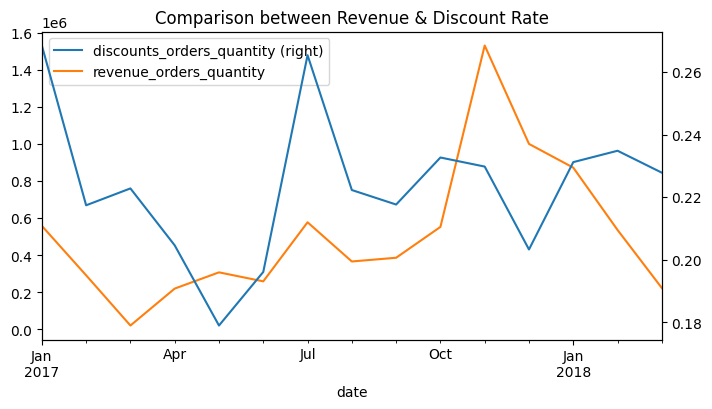

In [150]:
comparision_bw_revenue_discount_rate.plot(
    x="date",
    y=["discounts_orders_quantity", "revenue_orders_quantity"],
    secondary_y="discounts_orders_quantity",
    figsize=(8, 4),
    title="Comparison between Revenue & Discount Rate")

In [151]:
Q_comparision_bw_revenue_discount_rate = brands_orders_orderlines_products.resample("QE", on = "date"). agg(discounts_orders_quantity = ("discount","mean"),revenue_orders_quantity = ("unit_total", "sum")).reset_index()

<Axes: title={'center': 'QUARTILE Comparison between Revenue & Discount Rate'}, xlabel='date'>

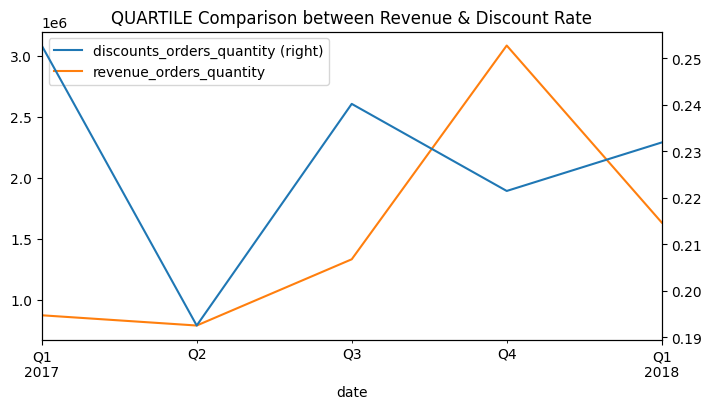

In [152]:
Q_comparision_bw_revenue_discount_rate.plot(
    x="date",
    y=["discounts_orders_quantity", "revenue_orders_quantity"],
    secondary_y="discounts_orders_quantity",
    figsize=(8, 4),
    title="QUARTILE Comparison between Revenue & Discount Rate")

# Comparision with Quarters

In [153]:
quarters =  brands_orders_orderlines_products.query("date.dt.quarter == 1").copy()
quarters ["percentage_discount"] = 1 - quarters ["unit_price"]

In [154]:
orderlines_df = orderlines_df.reset_index(drop=True)

In [155]:
orderlines_df

,order_id,product_quantity,sku,unit_price,date,unit_total
0,299545,1,OWC0100,47.49,2017-01-01 01:46:16,47.49
1,299546,1,IOT0014,18.99,2017-01-01 01:50:34,18.99
2,295347,1,APP0700,72.19,2017-01-01 01:54:11,72.19
3,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,60.90
4,299561,1,PEB0015,142.49,2017-01-01 02:38:50,142.49
...,...,...,...,...,...,...
55223,525664,1,TUC0207,16.52,2018-03-14 11:45:05,16.52
55224,527070,2,APP0698,9.99,2018-03-14 11:49:01,19.98
55225,527074,2,APP0698,9.99,2018-03-14 11:49:36,19.98
55226,527096,3,APP0698,9.99,2018-03-14 11:54:35,29.97


<Axes: xlabel='date'>

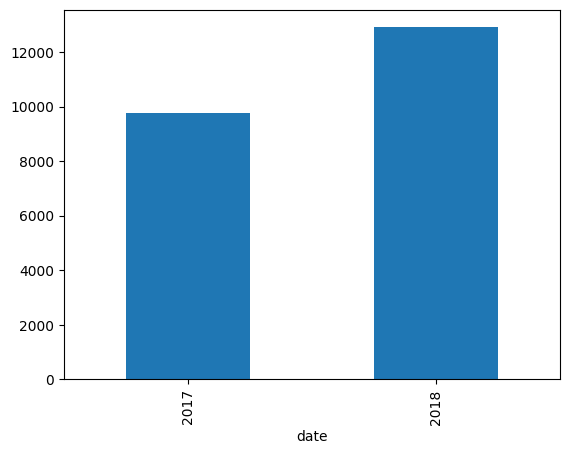

In [176]:
quarters.groupby(quarters["date"].dt.year)["product_quantity"].sum().plot(kind="bar")

# What are brands with the highest revenue?

In [156]:
most_revenue_brands = brands_orders_orderlines_products.groupby("long")["revenue"].sum().sort_values(ascending=False).reset_index().head(10)
most_revenue_brands

,long,revenue
0,Apple,2517851.38
1,Pack,483869.89
2,OWC,464627.12
3,LaCie,418470.35
4,Western Digital,368089.46
5,LG,321100.41
6,Crucial,282660.37
7,Wacom,279108.70
8,Dell,262109.29
9,Synology,162318.68


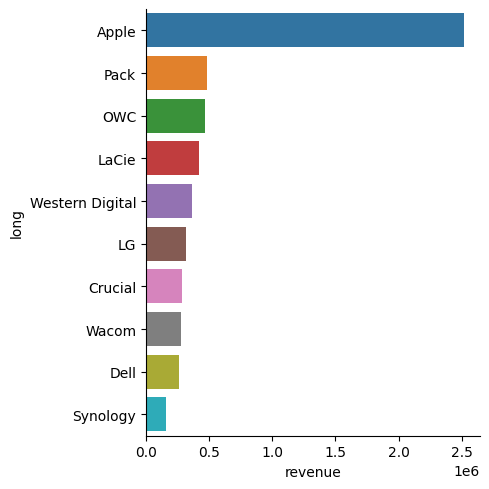

In [157]:
sns.catplot(
    kind="bar",
    data=most_revenue_brands,
    x='revenue',
    y='long',
    hue='long'
);

In [158]:
# count total orders of each brand
most_orders_brands = brands_orders_orderlines_products.groupby("long")["product_quantity"].sum().sort_values(ascending=False).reset_index().head(10)
most_orders_brands

,long,product_quantity
0,Apple,11254
1,OWC,3962
2,Western Digital,2435
3,Belkin,2337
4,Crucial,2163
5,LaCie,2014
6,Satechi,1889
7,Pack,1830
8,Wacom,1824
9,NewerTech,1719


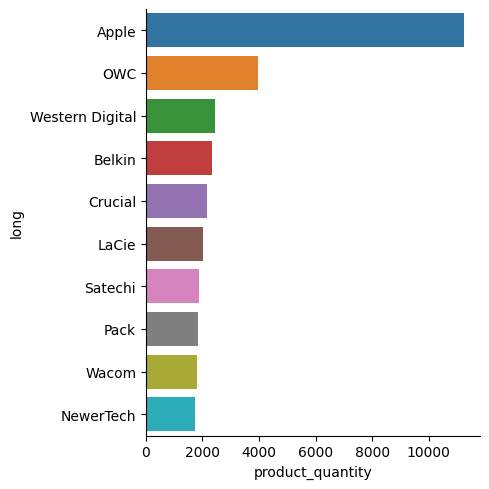

In [159]:
sns.catplot(
    kind="bar",
    data=most_orders_brands,
    x='product_quantity',
    y='long',
    hue='long'
);

In [160]:
colors_1 = {cat : "teal" if cat == "Pack" else "lightgrey" for cat in most_revenue_brands["long"]}

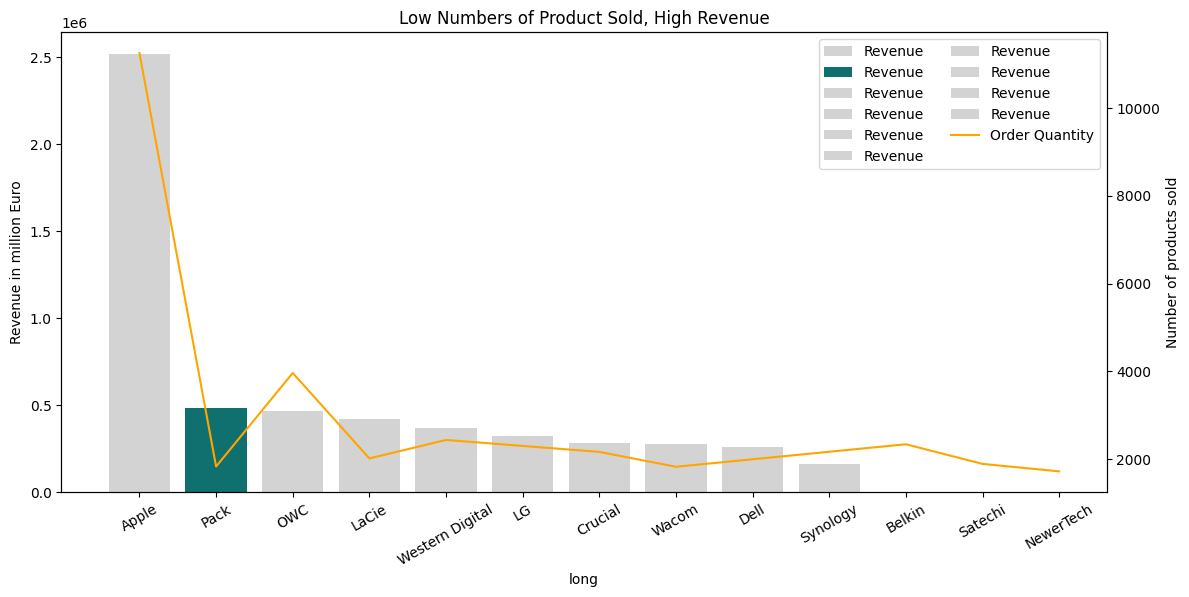

In [161]:
fig, ax1 = plt.subplots(1,1, figsize=(12,6))

sns.barplot(
    most_revenue_brands,
    x="long",
    y="revenue",
    hue="long",
    palette=colors_1,
    estimator="sum",
    errorbar="sd",
    ax=ax1,
    label="Revenue"
)
ax2 = ax1.twinx()
sns.lineplot(
    data=most_orders_brands,
    x="long",
    y="product_quantity",
    estimator="sum",
    color="orange",
    ax=ax2,
    label="Order Quantity",
    legend=False
)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1+handles2, labels1+labels2, loc="upper right", ncol=2)
ax1.tick_params(axis="x", rotation=30)
plt.tight_layout()

ax1.set_title("Low Numbers of Product Sold, High Revenue")
ax1.set(ylabel='Revenue in million Euro')
ax2.set(ylabel='Number of products sold');

In [162]:
colors_2 = {cat : "orange" if cat == "OWC" else "lightgrey" for cat in most_revenue_brands["long"]}

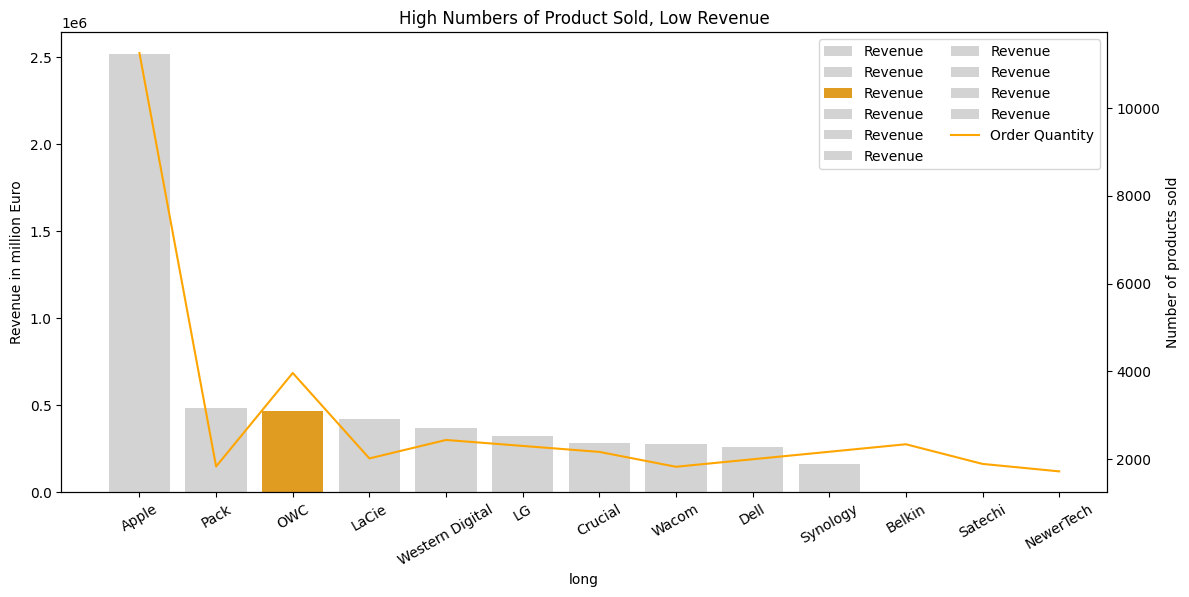

In [163]:
fig, ax1 = plt.subplots(1,1, figsize=(12,6))

sns.barplot(
    most_revenue_brands,
    x="long",
    y="revenue",
    hue="long",
    palette=colors_2,
    estimator="sum",
    errorbar="sd",
    ax=ax1,
    label="Revenue"
)
ax2 = ax1.twinx()
sns.lineplot(
    data=most_orders_brands,
    x="long",
    y="product_quantity",
    estimator="sum",
    color="orange",
    ax=ax2,
    label="Order Quantity",
    legend=False
)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1+handles2, labels1+labels2, loc="upper right", ncol=2)
ax1.tick_params(axis="x", rotation=30)
plt.tight_layout()

ax1.set_title("High Numbers of Product Sold, Low Revenue")
ax1.set(ylabel='Revenue in million Euro')
ax2.set(ylabel='Number of products sold');

# What are the products that generate the most revenue?

In [164]:
most_revenue_categories = brands_orders_orderlines_products.groupby("category")["revenue"].sum().sort_values(ascending=False).reset_index().head(10)
most_revenue_categories

,category,revenue
0,Storage Devices,2594248.87
1,Smartphones & Mobiles,1133222.88
2,Computers,734658.55
3,Accessories,573028.31
4,Wearables,421308.28
5,Tablets,384450.84
6,Audio & Visual Equipment,277310.98
7,Refurbish Products,219284.91
8,Smartphone & Mobile Accessories,188295.45
9,Power & Charging,166893.81


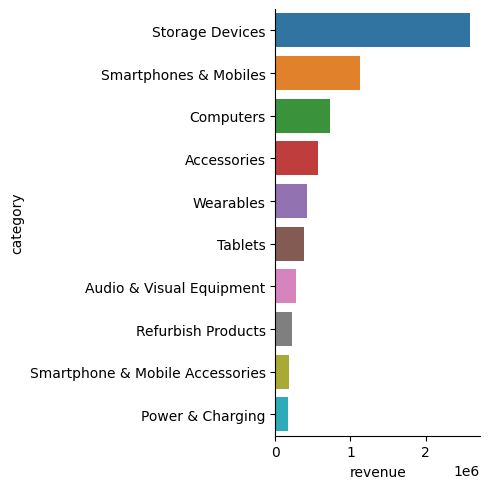

In [165]:
sns.catplot(
    kind="bar",
    data=most_revenue_categories,
    x='revenue',
    y='category',
    hue='category'
);

In [166]:
most_orders_categories = brands_orders_orderlines_products.groupby("category")["product_quantity"].sum().sort_values(ascending=False).reset_index().head(10)
most_orders_categories

,category,product_quantity
0,Storage Devices,17435
1,Accessories,7135
2,Smartphone & Mobile Accessories,5858
3,Computers,4036
4,Cables & Adapters,3602
5,Power & Charging,3119
6,Wearables,2839
7,Audio & Visual Equipment,2457
8,Smartphones & Mobiles,2290
9,Networking & Connectivity,2229


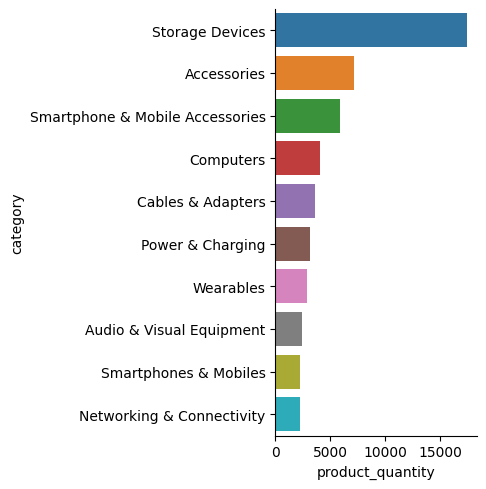

In [167]:
sns.catplot(
    kind="bar",
    data=most_orders_categories,
    x='product_quantity',
    y='category',
    hue='category'
);

In [168]:
colors1 = {cat : "teal" if cat == "Smartphones & Mobiles" else "lightgrey" for cat in most_revenue_categories["category"]}

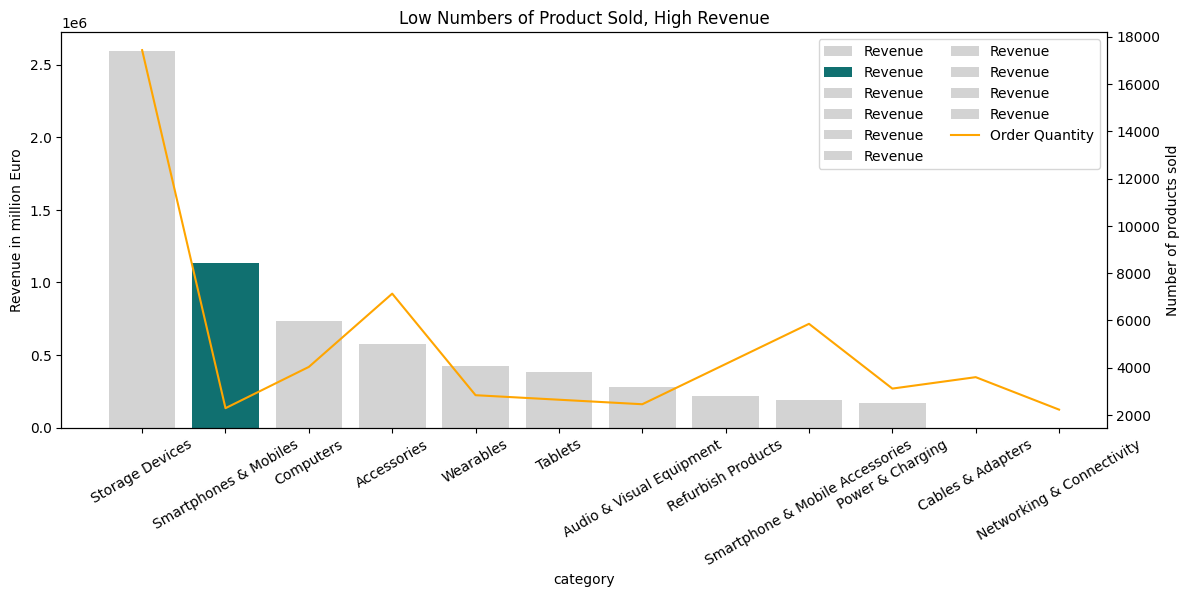

In [169]:
fig, ax1 = plt.subplots(1,1, figsize=(12,6))

sns.barplot(
    most_revenue_categories,
    x="category",
    y="revenue",
    hue="category",
    palette=colors1,
    estimator="sum",
    errorbar="sd",
    ax=ax1,
    label="Revenue"
)
ax2 = ax1.twinx()
sns.lineplot(
    data=most_orders_categories,
    x="category",
    y="product_quantity",
    estimator="sum",
    color="orange",
    ax=ax2,
    label="Order Quantity",
    legend=False
)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1+handles2, labels1+labels2, loc="upper right", ncol=2)
ax1.tick_params(axis="x", rotation=30)
plt.tight_layout()

ax1.set_title("Low Numbers of Product Sold, High Revenue")
ax1.set(ylabel='Revenue in million Euro')
ax2.set(ylabel='Number of products sold');

In [170]:
colors2 = {cat : "orange" if cat == "Smartphone & Mobile Accessories" else "lightgrey" for cat in most_revenue_categories["category"]}

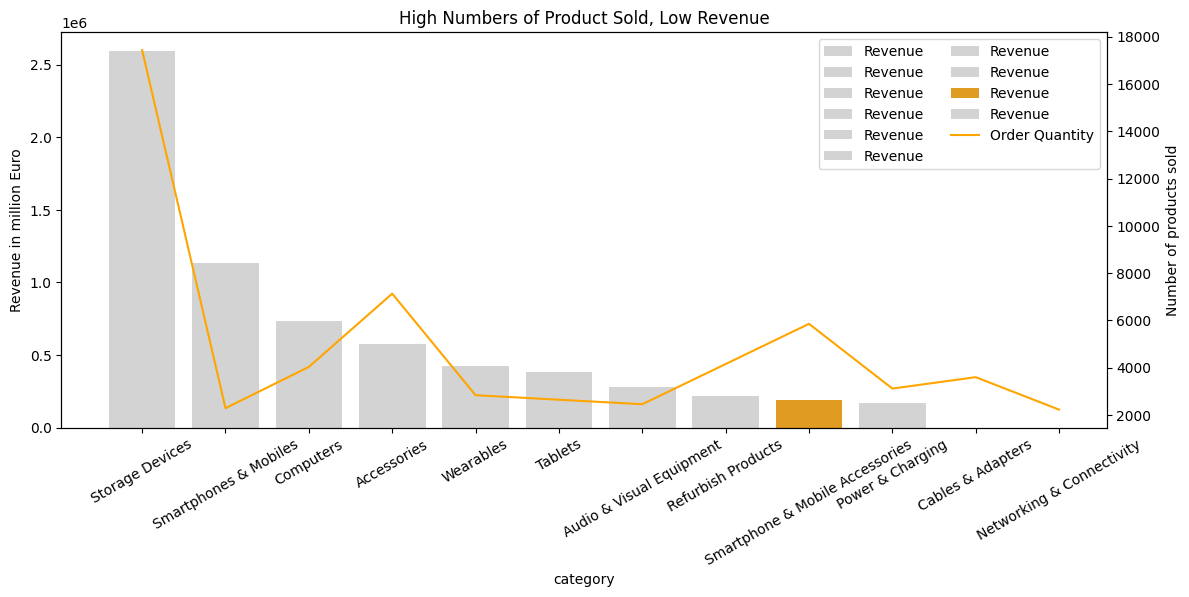

In [171]:
fig, ax1 = plt.subplots(1,1, figsize=(12,6))

sns.barplot(
    most_revenue_categories,
    x="category",
    y="revenue",
    hue="category",
    palette=colors2,
    estimator="sum",
    errorbar="sd",
    ax=ax1,
    label="Revenue"
)
ax2 = ax1.twinx()
sns.lineplot(
    data=most_orders_categories,
    x="category",
    y="product_quantity",
    estimator="sum",
    color="orange",
    ax=ax2,
    label="Order Quantity",
    legend=False
)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1+handles2, labels1+labels2, loc="upper right", ncol=2)
ax1.tick_params(axis="x", rotation=30)
plt.tight_layout()

ax1.set_title("High Numbers of Product Sold, Low Revenue")
ax1.set(ylabel='Revenue in million Euro')
ax2.set(ylabel='Number of products sold');

# What is the distribution of product prices across different categories?

In [172]:
distribution_price_by_category = (
    brands_orders_orderlines_products
    .groupby("category")
    ["price"].mean().sort_values(ascending=False))
distribution_price_by_category.reset_index()

,category,price
0,Refurbish Products,653.637379
1,Electrical Small Vehicles,544.454545
2,Smartphones & Mobiles,539.279371
3,Tablets,318.563103
4,Monitors,279.154407
5,Security & Surveillance,241.214286
6,Computer Softwares,235.498800
7,Computers,213.500020
8,Storage Devices,196.955949
9,Wearables,195.939769


In [173]:
distribution_price_by_category.info()

<class 'pandas.core.series.Series'>
Index: 25 entries, Refurbish Products to Repair & Services
Series name: price
Non-Null Count  Dtype  
--------------  -----  
25 non-null     float64
dtypes: float64(1)
memory usage: 400.0+ bytes


In [174]:
distribution_1 = pd.DataFrame(data=distribution_price_by_category.index, columns=['category'])
distribution_2 = pd.DataFrame(data=distribution_price_by_category.values, columns=['price'])
distribution_price = pd.merge(distribution_1, distribution_2, left_index=True, right_index=True)

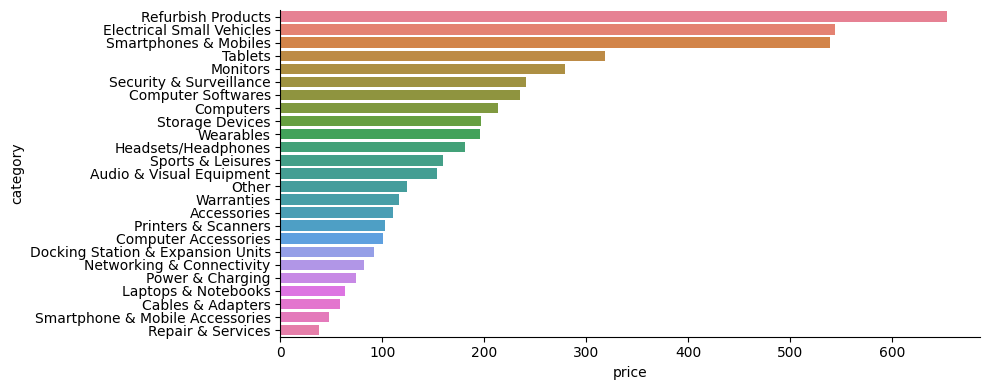

In [175]:
sns.catplot(
    kind="bar",
    data=distribution_price,
    x='price',
    y='category',
    hue='category',
    height=4,
    aspect=2.5
);